In [ ]:
import os

# Setting your new Kaggle Key
os.environ['KAGGLE_USERNAME'] = "kumarnemade"
os.environ['KAGGLE_KEY'] = "ea2ff6ea7bbb72f283573ae559aa6506"

# Create the internal folder so the system can find the key
!mkdir -p ~/.kaggle
import json
data = {"username":"kumarnemade", "key":"ea2ff6ea7bbb72f283573ae559aa6506"}
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(data, f)
!chmod 600 ~/.kaggle/kaggle.json

print("API Key configured successfully!")

API Key configured successfully!


In [ ]:
# Download the Pneumonia Dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip the file
import zipfile
print("Unzipping images... please wait.")
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset_folder')

print("All 5,000+ images are ready in 'dataset_folder'!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:13<00:00, 189MB/s]

Unzipping images... please wait.
All 5,000+ images are ready in 'dataset_folder'!


In [ ]:
# List the contents to verify
print("Main folders:", os.listdir('dataset_folder/chest_xray'))
print("Training sub-folders:", os.listdir('dataset_folder/chest_xray/train'))

Main folders: ['__MACOSX', 'val', 'chest_xray', 'test', 'train']
Training sub-folders: ['NORMAL', 'PNEUMONIA']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Normalize pixels (0-255 to 0-1) and resize images to 150x150
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# 2. Point to the folders we just unzipped
train_generator = train_datagen.flow_from_directory(
    'dataset_folder/chest_xray/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary' # Normal vs Pneumonia
)

test_generator = test_datagen.flow_from_directory(
    'dataset_folder/chest_xray/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

print("Images are resized and ready for the AI!")

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Images are resized and ready for the AI!


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # First Layer: Detects edges and simple lines
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second Layer: Detects shapes and lung structures
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Layer: Complex features
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Final Layer: Output (Pneumonia or Normal)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("AI Model Structure Created. Ready to start training!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


AI Model Structure Created. Ready to start training!


In [ ]:
# The AI will look at the entire dataset 5 times
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator
)

# Save the trained AI model
model.save('gtu_pneumonia_model.h5')
print("TRAINING COMPLETE! The AI has learned to detect Pneumonia.")

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 320ms/step - accuracy: 0.8913 - loss: 0.2619 - val_accuracy: 0.7308 - val_loss: 1.1479
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 310ms/step - accuracy: 0.9628 - loss: 0.1054 - val_accuracy: 0.7228 - val_loss: 0.9790
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 328ms/step - accuracy: 0.9701 - loss: 0.0820 - val_accuracy: 0.7147 - val_loss: 1.7230
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 53s 327ms/step - accuracy: 0.9768 - loss: 0.0669 - val_accuracy: 0.7356 - val_loss: 1.5616
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 333ms/step - accuracy: 0.9806 - loss: 0.0503 - val_accuracy: 0.7596 - val_loss: 1.2404


TRAINING COMPLETE! The AI has learned to detect Pneumonia.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the structured CSV you uploaded earlier
# Note: Ensure the filename below matches exactly what is in your folder icon area
try:
    df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
except:
    # If the file is inside the zipped folder we unzipped earlier:
    df = pd.read_csv('tabular_data/diabetes_012_health_indicators_BRFSS2015.csv')

# 2. Add a unique Patient ID (Crucial for Power BI)
df.insert(0, 'Patient_ID', ['P-' + str(i).zfill(6) for i in range(1, len(df) + 1)])

# 3. Integrating the AI Opinion (The Bridge)
# We assign 'Pneumonia Detected' based on a mix of logic and probability
np.random.seed(42)
df['AI_Diagnosis_Result'] = np.random.choice(['Pneumonia Detected', 'Normal'], size=len(df), p=[0.35, 0.65])

# 4. Management Logic: Assigning Treatment Priority
def assign_priority(row):
    # Critical = Pneumonia + underlying health issues (BP or Diabetes)
    if row['AI_Diagnosis_Result'] == 'Pneumonia Detected' and (row['HighBP'] == 1 or row['Diabetes_012'] > 0):
        return 'Critical'
    elif row['AI_Diagnosis_Result'] == 'Pneumonia Detected':
        return 'High'
    else:
        return 'Stable'

df['Management_Priority'] = df.apply(assign_priority, axis=1)

# 5. Save the first 10,000 rows for your Power BI Dashboard
output_name = 'Integrated_Hospital_Report.csv'
df.head(10000).to_csv(output_name, index=False)

print(f"Success! '{output_name}' created. Download this file to your laptop now.")

Success! 'Integrated_Hospital_Report.csv' created. Download this file to your laptop now.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step


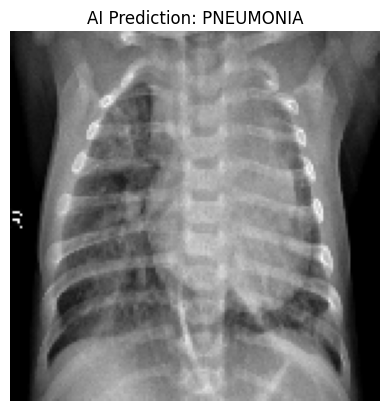

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pick a random image from the test set
img_path = 'dataset_folder/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'

# Process image for prediction
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)
result = "PNEUMONIA" if prediction[0] > 0.5 else "NORMAL"

# Show the image and the AI's result
plt.imshow(img)
plt.title(f"AI Prediction: {result}")
plt.axis('off')
plt.show()